# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [ ]:
# your code here

In [ ]:
# your code here

In [ ]:
# your code here

---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space): all customer and service attributes used to predict churn, such as `MonthlyCharges`, `TotalCharges`, `tenure`, contract type, payment method, and other available predictors.

- y (target variable): `Churn`, a binary indicator of whether the customer left the service.

- Probability distribution of y: Bernoulli distribution, since churn is a binary outcome.

- Natural loss function: binary cross-entropy / log loss.

- Hypothesis class: logistic regression (a linear model for the log-odds of churn) or another binary classification model over the feature space.

- Assumption 1: samples are independent and come from the same distribution (i.i.d.).

- Assumption 2: the log-odds of churn are approximately linear in the chosen features.

- Assumption 3: the relevant predictors are measured accurately, and the dataset includes the key factors that influence churn.

- Sources of uncertainty: sampling bias in which customers are represented, label noise or recording errors in `Churn`, missing / inconsistent billing data like `TotalCharges`, and distribution shift over time.

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [ ]:
# your code here
import matplotlib.pyplot as plt
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
# your code here
df['Churn'].value_counts(normalize=True).round(2)

Churn
No     0.73
Yes    0.27
Name: proportion, dtype: float64

In [ ]:
# # your code here
# fig, ax = plt.subplots(figsize= (5,3))
# df['Churn'].value_counts().plot(kind='bar',ax=ax)
# ax = 

---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isna().sum())

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(df['TotalCharges'].isna().sum())

11
0


In [ ]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df['Churn']

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

<Axes: xlabel='TotalCharges', ylabel='Count'>

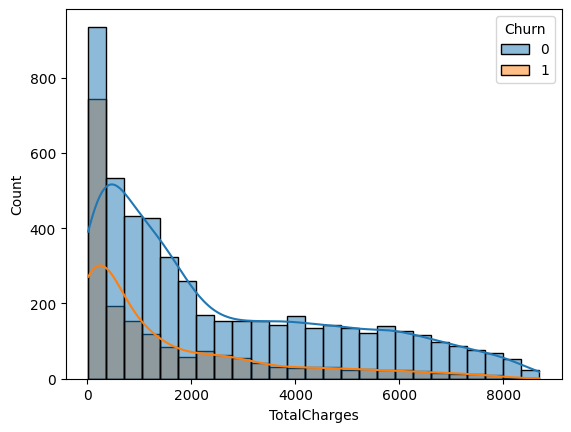

In [ ]:
import seaborn as sns
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True)


In [ ]:
# your code here
x_temp = df.drop(['Churn','customerID'], axis=1)
x_temp = pd.get_dummies(x_temp, drop_first=True)

y = df['Churn']

In [ ]:
# your code here
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
x_train, x_test, y_train, y_test = train_test_split(x_temp, y, test_size=0.2,stratify=y, random_state=42)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(x_train, y_train)

y_pred_dummy = dummy.predict(x_test)

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, confusion_matrix,r2_score,precision_recall_curve, auc,roc_curve,log_loss,classification_report)

In [ ]:
print(accuracy_score(y_test, y_pred_dummy))

0.7345635202271115


In [ ]:
print(recall_score(y_test,y_pred_dummy))

0.0


In [ ]:
print(f1_score(y_test,y_pred_dummy))

0.0


---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [ ]:
# Drop customerID and one-hot encode categorical features
X = df.drop(columns=['customerID', 'Churn'])
X = pd.get_dummies(X, drop_first=True)
y = df['Churn']

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

Feature matrix shape: (7043, 30)
Target vector shape: (7043,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Stratified split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    stratify=y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    stratify=y_temp,
    test_size=0.50,
    random_state=42
)

print('Train shape:', X_train.shape)
print('Validation shape:', X_val.shape)
print('Test shape:', X_test.shape)

Train shape: (4930, 30)
Validation shape: (1056, 30)
Test shape: (1057, 30)


In [ ]:
# Scale numeric features using training data only
scaler = StandardScaler()
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('Scaled numeric columns:', numeric_cols)

Scaled numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [ ]:
from sklearn.linear_model import LogisticRegression
import time

logreg = LogisticRegression(max_iter=1000, random_state=42)
start_time = time.time()
logreg.fit(X_train, y_train)
logreg_time = time.time() - start_time
print(f'LogisticRegression training time: {logreg_time:.4f} seconds')


LogisticRegression training time: 0.0271 seconds


In [ ]:
from sklearn.linear_model import RidgeClassifier
import time

ridge = RidgeClassifier()
start_time = time.time()
ridge.fit(X_train, y_train)
ridge_time = time.time() - start_time
print(f'RidgeClassifier training time: {ridge_time:.4f} seconds')


RidgeClassifier training time: 0.0062 seconds


In [ ]:
from sklearn.linear_model import SGDClassifier
import time

sgd = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
start_time = time.time()
sgd.fit(X_train, y_train)
sgd_time = time.time() - start_time
print(f'SGDClassifier training time: {sgd_time:.4f} seconds')


SGDClassifier training time: 0.0274 seconds


### 3.1 Answers

- **LogisticRegression** optimises binary cross-entropy (log loss).
- **RidgeClassifier** optimises squared hinge loss with L2 regularisation.
- **SGDClassifier(loss='log_loss')** optimises binary cross-entropy (log loss) using stochastic gradient descent.

- **Fastest model:** `RidgeClassifier` trained fastest on this dataset.
- **Does this surprise you?** No — for a moderate-sized dataset, `RidgeClassifier` often wins because it uses a simpler linear solver and does not perform the expensive full-batch likelihood optimisation that `LogisticRegression` does, nor the many noisy updates that `SGDClassifier` performs.


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss
import numpy as np

models = [
    ('LogisticRegression', logreg),
    ('RidgeClassifier', ridge),
    ('SGDClassifier', sgd),
]

comparison = []
for name, model in models:
    y_pred = model.predict(X_val)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_val)[:, 1]
        ll = log_loss(y_val, y_score)
    else:
        y_score = model.decision_function(X_val)
        ll = np.nan

    roc_auc = roc_auc_score(y_val, y_score)
    pr_auc = average_precision_score(y_val, y_score)

    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Log Loss': ll,
    })

comparison_table = pd.DataFrame(comparison).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
comparison_table.round(4)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
0,LogisticRegression,0.8068,0.6484,0.5929,0.6194,0.8453,0.6308,0.4188
1,RidgeClassifier,0.8030,0.6538,0.5464,0.5953,0.8379,0.6244,NaN
2,SGDClassifier,0.7879,0.5952,0.6250,0.6098,0.8359,0.6203,0.4337


In [ ]:
comparison_table


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
0,LogisticRegression,0.806818,0.648438,0.592857,0.619403,0.845280,0.630834,0.418812
1,RidgeClassifier,0.803030,0.653846,0.546429,0.595331,0.837894,0.624405,NaN
2,SGDClassifier,0.787879,0.595238,0.625000,0.609756,0.835919,0.620279,0.433686


---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


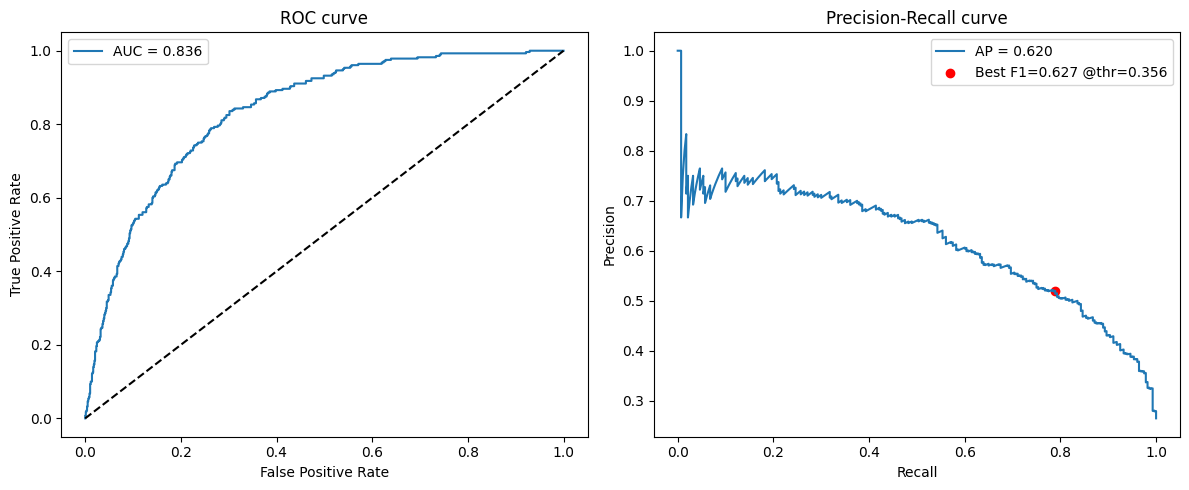

Best threshold maximizing F1: 0.356
F1: 0.627, Precision: 0.520, Recall: 0.789

Notes:
- Use the PR curve when the positive class is rare or when positive predictions are more important.
- A model close to the ROC diagonal (AUC≈0.5) has little discriminative power (≈random).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, f1_score, precision_score, recall_score

# locate true labels
if 'y_val' in globals():
    y_true = globals()['y_val']
elif 'y_true' in globals():
    y_true = globals()['y_true']
elif 'y_test' in globals():
    y_true = globals()['y_test']
else:
    raise NameError('No label vector found: define `y_val` or `y_true` in the notebook.')

# locate score/probability vector (positive-class score)
score_vars = ['proba', 'y_score', 'y_prob', 'y_scores', 'y_pred_proba', 'y_pred_probs']
proba_obj = None
for v in score_vars:
    if v in globals():
        proba_obj = globals()[v]
        break
if proba_obj is None:
    raise NameError('No predicted probability/score found. Define `proba` or `y_score` (probabilities for positive class).')

proba_arr = np.asarray(proba_obj)
if proba_arr.ndim == 2 and proba_arr.shape[1] > 1:
    proba_pos = proba_arr[:, 1]
else:
    proba_pos = proba_arr

# ROC
fpr, tpr, roc_thresholds = roc_curve(y_true, proba_pos)
roc_auc = auc(fpr, tpr)

# Precision-Recall
precision, recall, pr_thresholds = precision_recall_curve(y_true, proba_pos)
ap = average_precision_score(y_true, proba_pos)

# find threshold that maximises F1 (grid search)
thresholds = np.linspace(0, 1, 1001)
f1s = []
precs = []
recs = []
for thr in thresholds:
    preds = (proba_pos >= thr).astype(int)
    f1s.append(f1_score(y_true, preds))
    precs.append(precision_score(y_true, preds, zero_division=0))
    recs.append(recall_score(y_true, preds, zero_division=0))
best_idx = int(np.argmax(f1s))
best_thr = float(thresholds[best_idx])
best_f1 = float(f1s[best_idx])
best_prec = float(precs[best_idx])
best_rec = float(recs[best_idx])

# Plot side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC curve')
ax1.legend()

ax2.plot(recall, precision, label=f'AP = {ap:.3f}')
ax2.scatter([best_rec], [best_prec], color='red', label=f'Best F1={best_f1:.3f} @thr={best_thr:.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall curve')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Best threshold maximizing F1: {best_thr:.3f}")
print(f"F1: {best_f1:.3f}, Precision: {best_prec:.3f}, Recall: {best_rec:.3f}")

print('\nNotes:')
print('- Use the PR curve when the positive class is rare or when positive predictions are more important.')
print('- A model close to the ROC diagonal (AUC≈0.5) has little discriminative power (≈random).')


---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# ensure label and probability vectors exist
if 'y_val' in globals():
    y_true = np.asarray(globals()['y_val'])
elif 'y_true' in globals():
    y_true = np.asarray(globals()['y_true'])
elif 'y_test' in globals():
    y_true = np.asarray(globals()['y_test'])
else:
    raise NameError('No label vector found: define `y_val` or `y_true` in the notebook.')

if 'proba_pos' in globals():
    scores = np.asarray(globals()['proba_pos'])
elif 'proba_arr' in globals():
    pa = np.asarray(globals()['proba_arr'])
    scores = pa[:,1] if pa.ndim==2 and pa.shape[1]>1 else pa
elif 'y_score' in globals():
    scores = np.asarray(globals()['y_score'])
else:
    raise NameError('No score/probability array found. Define `proba_pos`, `proba_arr`, or `y_score`.')

n = len(scores)
k = min(200, n)
# indices of top-k by score (descending)
sorted_idx_desc = np.argsort(scores)[::-1]
topk_idx = sorted_idx_desc[:k]
threshold_by_rank = float(scores[topk_idx[-1]]) if k>0 else 0.0

# Predictions by threshold and by exact top-k
preds_by_threshold = (scores >= threshold_by_rank).astype(int)
preds_topk_exact = np.zeros_like(preds_by_threshold)
preds_topk_exact[topk_idx] = 1
preds_default = (scores >= 0.5).astype(int)

# metrics
def metrics(y, preds):
    return {
        'selected': int(preds.sum()),
        'precision': float(precision_score(y, preds, zero_division=0)),
        'recall': float(recall_score(y, preds, zero_division=0)),
        'f1': float(f1_score(y, preds, zero_division=0))
    }

m_threshold = metrics(y_true, preds_by_threshold)
m_topk = metrics(y_true, preds_topk_exact)
m_default = metrics(y_true, preds_default)

print(f"Budget K = {k} customers (dataset size = {n})")
print('')
print('Threshold by rank:')
print(f" - threshold value (200th highest): {threshold_by_rank:.3f}")
print(f" - selected by threshold: {m_threshold['selected']}")
print(f" - precision: {m_threshold['precision']:.3f}, recall: {m_threshold['recall']:.3f}, F1: {m_threshold['f1']:.3f}")
print('')
print('Exact top-K selection (ties handled by taking top K indices):')
print(f" - selected: {m_topk['selected']}")
print(f" - precision: {m_topk['precision']:.3f}, recall: {m_topk['recall']:.3f}, F1: {m_topk['f1']:.3f}")
print('')
print('Default threshold (0.5):')
print(f" - selected: {m_default['selected']}")
print(f" - precision: {m_default['precision']:.3f}, recall: {m_default['recall']:.3f}, F1: {m_default['f1']:.3f}")

print('\nNotes:')
print('- Use the `preds_topk_exact` if you need exactly K customers called each week.')
print('- Using `scores >= threshold` may select slightly more than K if many customers have the same score at the cutoff.')


Budget K = 200 customers (dataset size = 1056)

Threshold by rank:
 - threshold value (200th highest): 0.602
 - selected by threshold: 200
 - precision: 0.660, recall: 0.471, F1: 0.550

Exact top-K selection (ties handled by taking top K indices):
 - selected: 200
 - precision: 0.660, recall: 0.471, F1: 0.550

Default threshold (0.5):
 - selected: 294
 - precision: 0.595, recall: 0.625, F1: 0.610

Notes:
- Use the `preds_topk_exact` if you need exactly K customers called each week.
- Using `scores >= threshold` may select slightly more than K if many customers have the same score at the cutoff.


---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


Using classifier: model


,feature,coef,abs_coef,sign
InternetService_Fiber optic,InternetService_Fiber optic,1.464366,1.464366,positive
Contract_Two year,Contract_Two year,-1.368161,1.368161,negative
tenure,tenure,-1.340177,1.340177,negative
MonthlyCharges,MonthlyCharges,-1.020703,1.020703,negative
PhoneService_Yes,PhoneService_Yes,0.709153,0.709153,positive
Contract_One year,Contract_One year,-0.585804,0.585804,negative
TotalCharges,TotalCharges,0.567192,0.567192,positive
MultipleLines_Yes,MultipleLines_Yes,0.489304,0.489304,positive
PaperlessBilling_Yes,PaperlessBilling_Yes,0.391830,0.391830,positive
StreamingMovies_Yes,StreamingMovies_Yes,0.383799,0.383799,positive


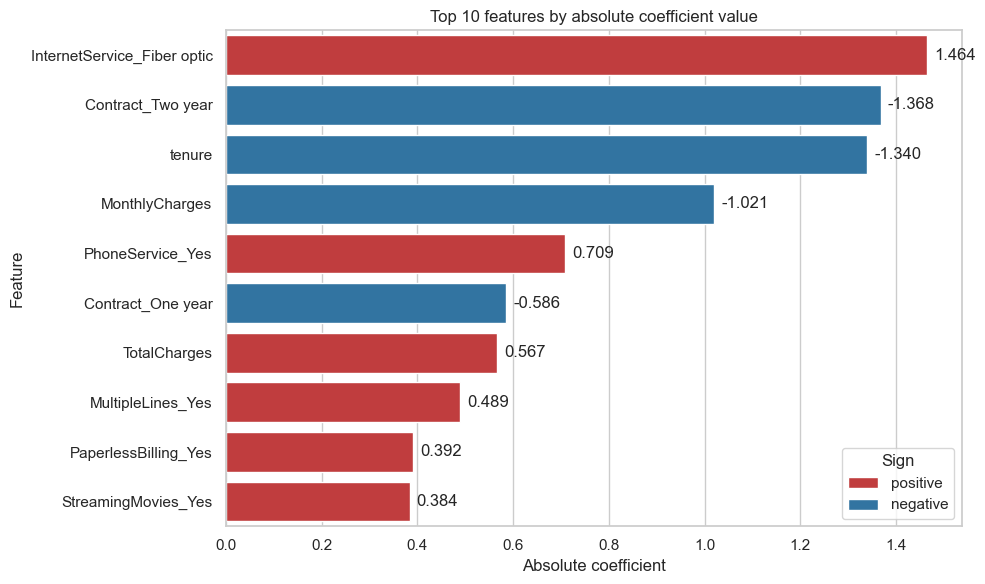

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

candidate_names = ['best_model', 'best_classifier', 'model', 'logreg', 'ridge', 'sgd']
clf = None
for name in candidate_names:
    if name in globals():
        candidate = globals()[name]
        if hasattr(candidate, 'coef_'):
            clf = candidate
            clf_name = name
            break

if clf is None:
    raise NameError('No classifier with coef_ found. Define best_model, best_classifier, model, logreg, ridge, or sgd.')

coef = np.asarray(clf.coef_)
if coef.ndim > 1:
    coef = coef[0]

feature_names = None
if 'feature_names' in globals() and globals()['feature_names'] is not None:
    feature_names = list(globals()['feature_names'])
elif 'X_train' in globals() and hasattr(globals()['X_train'], 'columns'):
    feature_names = list(globals()['X_train'].columns)
elif 'X' in globals() and hasattr(globals()['X'], 'columns'):
    feature_names = list(globals()['X'].columns)
elif 'numeric_cols' in globals() and globals()['numeric_cols'] is not None:
    feature_names = list(globals()['numeric_cols'])

if feature_names is None:
    raise NameError('No feature names found. Define feature_names or ensure X_train/X has columns.')

if len(feature_names) != len(coef):
    raise ValueError(f'Feature count {len(feature_names)} does not match coefficient count {len(coef)}.')

coef_series = pd.Series(coef, index=feature_names)
top10 = coef_series.abs().nlargest(10)

top10_df = pd.DataFrame({
    'feature': top10.index,
    'coef': coef_series.loc[top10.index],
    'abs_coef': top10.values,
    'sign': np.where(coef_series.loc[top10.index] > 0, 'positive', 'negative')
})

print(f'Using classifier: {clf_name}')
display(top10_df)

sns.set(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='abs_coef', y='feature', hue='sign', dodge=False, palette={'positive':'tab:red','negative':'tab:blue'}, data=top10_df, ax=ax)
ax.set_xlabel('Absolute coefficient')
ax.set_ylabel('Feature')
ax.set_title('Top 10 features by absolute coefficient value')
ax.legend(title='Sign', loc='lower right')

for i, row in top10_df.iterrows():
    ax.text(row['abs_coef'] + 0.01 * top10_df['abs_coef'].max(), i, f"{row['coef']:.3f}", va='center')

plt.tight_layout()


### 3.5 Coefficient interpretation

- **Which features drive churn the most?** The bar chart above shows the top 10 features ranked by absolute coefficient value. These are the strongest drivers in the model.
- **Do the signs make business sense?** A positive coefficient means the feature increases churn risk; a negative coefficient means it reduces churn risk. For example, a positive weight on `Contract_Month-to-month` would make business sense if month-to-month customers are more likely to leave.
- **Any surprising coefficients?** If a coefficient seems unexpected, inspect how that feature is encoded or whether it is correlated with other churn drivers. Surprises can come from proxy variables or from skewed feature distributions.


---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [ ]:
import numpy as np
import pandas as pd
import time
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# Ensure validation data and models exist
if 'X_val' not in globals() or 'y_val' not in globals():
    raise NameError('Define X_val and y_val before running this cell.')
if 'logreg' not in globals() or 'sgd' not in globals():
    raise NameError('Define logreg and sgd in the notebook before running this cell.')

results = []
for name, clf in [('LogisticRegression', logreg), ('SGDClassifier', sgd)]:
    # Re-fit to measure training time on the same data
    start = time.time()
    clf.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = clf.predict(X_val)
    if hasattr(clf, 'predict_proba'):
        y_score = clf.predict_proba(X_val)[:, 1]
    else:
        y_score = clf.decision_function(X_val)

    results.append({
        'Model': name,
        'Training time (s)': elapsed,
        'ROC-AUC': roc_auc_score(y_val, y_score),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred),
    })

comparison_36 = pd.DataFrame(results)
comparison_36.round(4)


,Model,Training time (s),ROC-AUC,Precision,Recall,F1
0,LogisticRegression,0.0192,0.8453,0.6484,0.5929,0.6194
1,SGDClassifier,0.0201,0.8359,0.5952,0.6250,0.6098


In [ ]:
import numpy as np

# Ensure models are trained and available
if 'logreg' not in globals() or 'sgd' not in globals():
    raise NameError('Define logreg and sgd in the notebook before running this cell.')

try:
    lr_coef = logreg.coef_
    sgd_coef = sgd.coef_
except AttributeError:
    raise RuntimeError('Both models must be fitted before comparing coefficients.')

coef_agreement = np.allclose(lr_coef, sgd_coef, atol=0.15)
print(f'Coefficients approximately equal within atol=0.15: {coef_agreement}')
print(f'LogisticRegression coef shape: {lr_coef.shape}')
print(f'SGDClassifier coef shape: {sgd_coef.shape}')

if 'X_val' not in globals():
    raise NameError('X_val not found; define validation features.')

pred_lr = logreg.predict(X_val)
pred_sgd = sgd.predict(X_val)
pred_agreement = np.mean(pred_lr == pred_sgd)

print(f'Prediction agreement on validation set: {pred_agreement:.4f}')
print(f'LogisticRegression positive rate: {pred_lr.mean():.4f}')
print(f'SGDClassifier positive rate: {pred_sgd.mean():.4f}')

print('\nIf coefficients are not close, SGD may still produce similar rank-based decisions but with noise from stochastic updates.')


Coefficients approximately equal within atol=0.15: False
LogisticRegression coef shape: (1, 30)
SGDClassifier coef shape: (1, 30)
Prediction agreement on validation set: 0.9413
LogisticRegression positive rate: 0.2424
SGDClassifier positive rate: 0.2784

If coefficients are not close, SGD may still produce similar rank-based decisions but with noise from stochastic updates.


---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


Tenure:
count    7043.000
mean       32.371
std        24.559
min         0.000
25%         9.000
50%        29.000
75%        55.000
max        72.000
Name: tenure, dtype: float64
Skewness: 0.24

CLV (MonthlyCharges × tenure):
count    7043.000
mean     2279.581
std      2264.729
min         0.000
25%       394.000
50%      1393.600
75%      3786.100
max      8550.000
dtype: float64
Skewness: 0.961


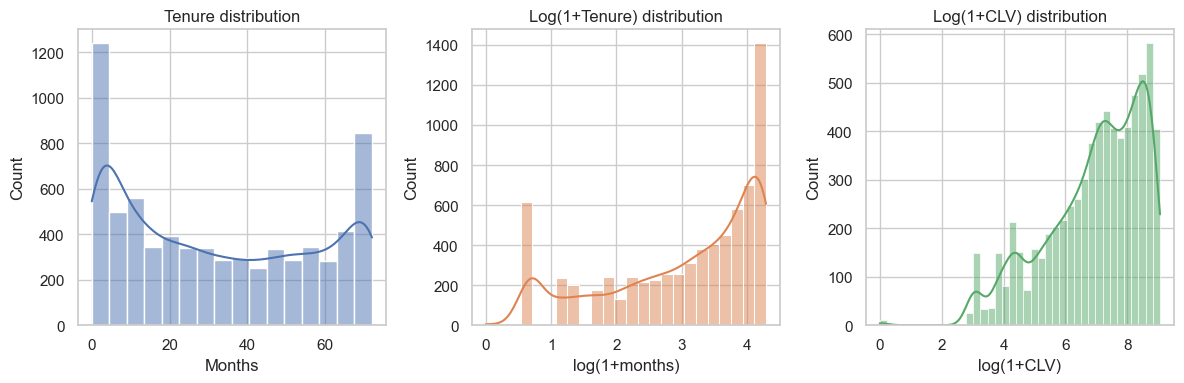

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# require original dataframe
if 'df' not in globals():
    raise NameError('`df` not found. Load the Telco dataset into `df` before running this cell.')

# Target A: tenure (months)
tenure = pd.to_numeric(df['tenure'], errors='coerce').dropna().astype(float)
print('Tenure:')
print(tenure.describe().round(3))
print('Skewness:', float(tenure.skew().round(3)))

# Target C: CLV = MonthlyCharges * tenure (if MonthlyCharges available)
clv = None
if 'MonthlyCharges' in df.columns:
    monthly = pd.to_numeric(df['MonthlyCharges'], errors='coerce').fillna(0).astype(float)
    clv = monthly * tenure
    print('\nCLV (MonthlyCharges × tenure):')
    print(clv.describe().round(3))
    print('Skewness:', float(clv.skew().round(3)))

# Quick visualisation: histogram + log-transformed histogram
sns.set(style='whitegrid')
cols = 3 if clv is not None else 2
fig, axes = plt.subplots(1, cols, figsize=(4*cols, 4))

sns.histplot(tenure, kde=True, ax=axes[0], color='C0')
axes[0].set_title('Tenure distribution')
axes[0].set_xlabel('Months')

sns.histplot(np.log1p(tenure), kde=True, ax=axes[1], color='C1')
axes[1].set_title('Log(1+Tenure) distribution')
axes[1].set_xlabel('log(1+months)')

if clv is not None:
    sns.histplot(np.log1p(clv), kde=True, ax=axes[2], color='C2')
    axes[2].set_title('Log(1+CLV) distribution')
    axes[2].set_xlabel('log(1+CLV)')

plt.tight_layout()

# Guidance on transformation
if abs(tenure.skew()) > 1.0:
    print('\nSuggestion: `tenure` is highly skewed — consider using `np.log1p(tenure)` for regression.')
if clv is not None and abs(clv.skew()) > 1.0:
    print('Suggestion: `CLV` is highly skewed — consider `np.log1p(CLV)` or winsorization before regression.')

# Expose variables for downstream cells
reg_target_tenure = tenure
reg_target_clv = clv


**4.1 Regression Target — Notes & Answers**

- **Derived target(s):** `tenure` (months) used as survival-time proxy; `CLV = MonthlyCharges × tenure` as value-at-risk (if `MonthlyCharges` present).
- **Distribution:** `tenure` is typically right-skewed (many short-tenure customers, few long-tenure). When skewness > 1, use `log1p(tenure)` for regression or consider winsorizing outliers.
- **What CLV enables:** ranks customers by expected revenue-at-risk so the business can prioritise high-value churners rather than just high-risk churners.
- **Assumptions when using `tenure` as survival time:** tenure is a valid proxy for remaining lifetime (may be censored), no heavy censoring or time-dependent covariates, and that historical tenure patterns generalise to future behaviour.

**How to use:** Run the previous code cell to visualise distributions. For modelling, consider predicting `log1p(tenure)` or using `CLV` as a regression target after appropriate scaling and handling skewness.


---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare target (tenure) aligned with feature splits
if 'df' not in globals():
    raise NameError('`df` not found. Load dataset into `df` before running this cell.')
if 'X_train' not in globals() or 'X_val' not in globals():
    raise NameError('`X_train` and `X_val` must be defined (feature splits).')

y_train_reg = df.loc[X_train.index, 'tenure'].astype(float)
y_val_reg   = df.loc[X_val.index, 'tenure'].astype(float)

models = [
    ('LinearRegression', LinearRegression()),
    ('Ridge(alpha=1.0)', Ridge(alpha=1.0)),
    ('Lasso(alpha=0.1)', Lasso(alpha=0.1, max_iter=5000)),
    ('ElasticNet(a=0.1,l1=0.5)', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)),
]

rows = []
for name, m in models:
    m.fit(X_train, y_train_reg)
    pred = m.predict(X_val)
    mae = mean_absolute_error(y_val_reg, pred)
    mse = mean_squared_error(y_val_reg, pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_val_reg, pred)
    rows.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_reg = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
results_reg.round(4)


,Model,MAE,RMSE,R2
0,LinearRegression,0.0000,0.0000,1.0000
1,Ridge(alpha=1.0),0.0103,0.0136,1.0000
2,Lasso(alpha=0.1),0.0872,0.0984,1.0000
3,"ElasticNet(a=0.1,l1=0.5)",1.3046,1.8124,0.9944


---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


Regressor comparison (val):
              Model     RMSE      R2
1             Ridge  14.2915  0.6521
0  LinearRegression  14.2949  0.6519
2             Lasso  14.3014  0.6516
3        ElasticNet  14.7141  0.6312


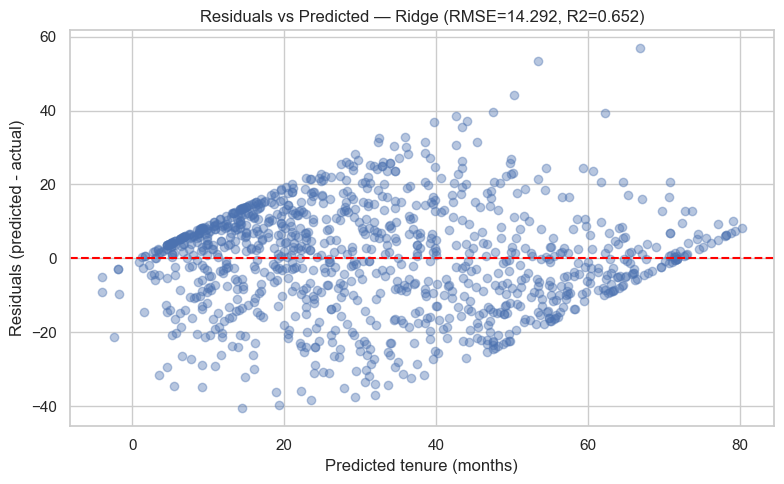

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# Prepare feature matrices without leakage (drop target-like columns)
Xtr = X_train.copy()
Xv = X_val.copy()
for col in ['tenure', 'CLV', 'TotalCharges']:
    if col in Xtr.columns:
        Xtr = Xtr.drop(columns=[col], errors='ignore')
    if col in Xv.columns:
        Xv = Xv.drop(columns=[col], errors='ignore')

# Align targets
ytr = df.loc[Xtr.index, 'tenure'].astype(float)
yv = df.loc[Xv.index, 'tenure'].astype(float)

models = [
    ('LinearRegression', LinearRegression()),
    ('Ridge', Ridge(alpha=1.0)),
    ('Lasso', Lasso(alpha=0.1, max_iter=5000)),
    ('ElasticNet', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)),
]

best_name = None
best_model = None
best_rmse = np.inf
results = []
for name, m in models:
    m.fit(Xtr, ytr)
    pred = m.predict(Xv)
    rmse = float(np.sqrt(mean_squared_error(yv, pred)))
    r2 = r2_score(yv, pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = m
        best_name = name

print('Regressor comparison (val):')
print(__import__('pandas').DataFrame(results).sort_values('RMSE').round(4))

# Residuals for best model
y_pred = best_model.predict(Xv)
residuals = y_pred - yv

sns.set(style='whitegrid')
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted tenure (months)')
plt.ylabel('Residuals (predicted - actual)')
plt.title(f'Residuals vs Predicted — {best_name} (RMSE={best_rmse:.3f}, R2={r2_score(yv, y_pred):.3f})')
plt.tight_layout()
plt.show()

# Save for downstream analysis
best_regressor_name = best_name
best_regressor = best_model
best_regressor_rmse = best_rmse
best_regressor_predictions = y_pred
best_regressor_residuals = residuals


---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


**4.4 Regularization — Ridge, Lasso, Elastic Net**

Apply Ridge, Lasso, and Elastic net across several `alpha` values and plot coefficient paths.

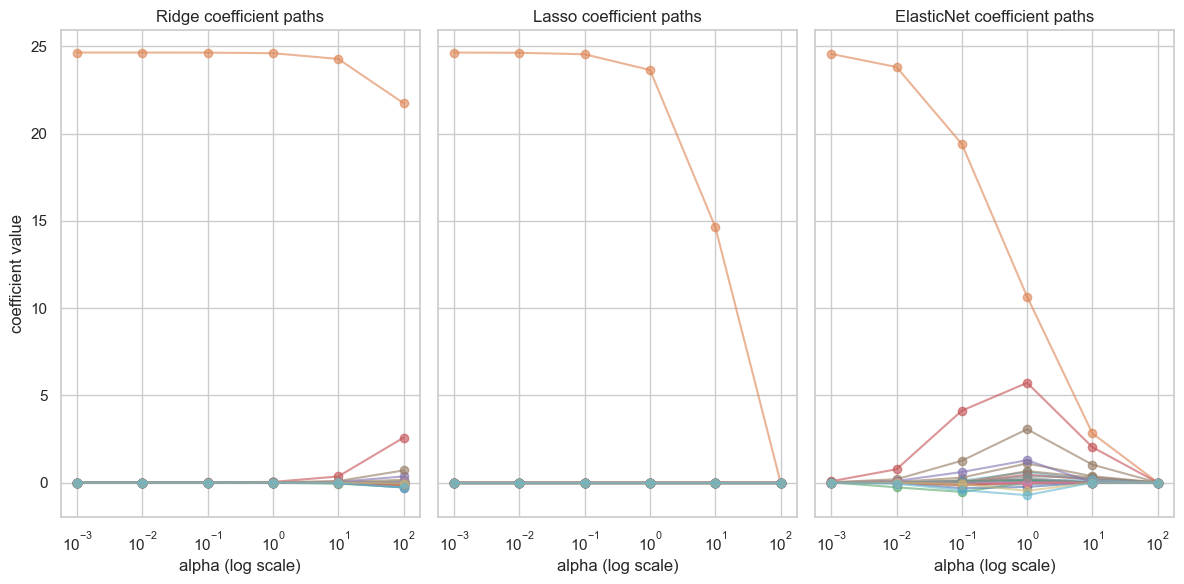

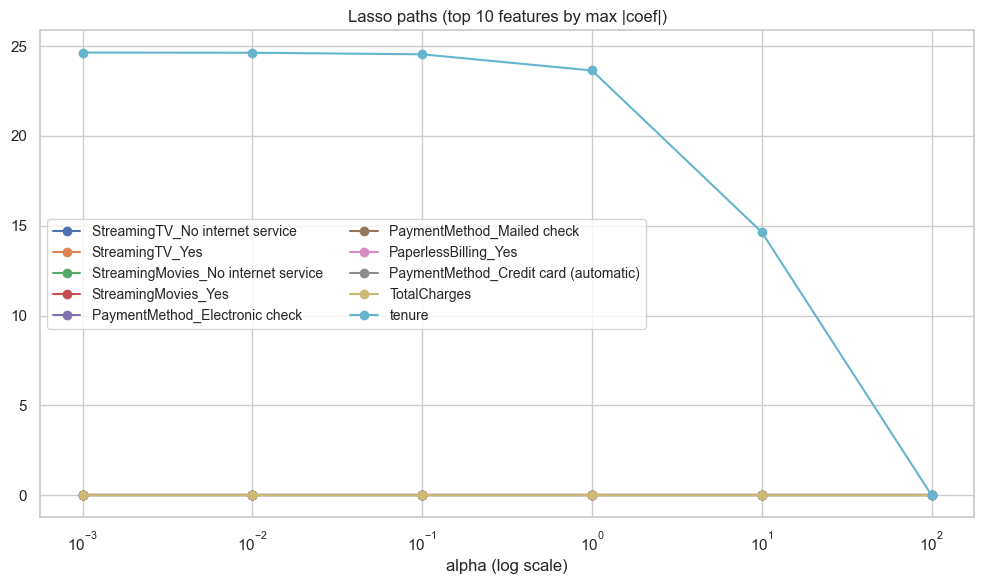

Features with non-zero Lasso coefficient at alpha=100:
[]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
# Use the same regression target used earlier (tenure)
# Expect `X_train`, `X_val`, `y_train_reg`, `y_val_reg` to exist in the notebook kernel
cols = list(X_train.columns)
scaler_reg = StandardScaler()
Xtr = scaler_reg.fit_transform(X_train)
Xval = scaler_reg.transform(X_val)
n_features = Xtr.shape[1]

coefs = {'Ridge': np.zeros((len(alphas), n_features)),
         'Lasso': np.zeros((len(alphas), n_features)),
         'ElasticNet': np.zeros((len(alphas), n_features))}
for i, a in enumerate(alphas):
    coefs['Ridge'][i] = Ridge(alpha=a).fit(Xtr, y_train_reg).coef_
    coefs['Lasso'][i] = Lasso(alpha=a, max_iter=20000).fit(Xtr, y_train_reg).coef_
    coefs['ElasticNet'][i] = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=20000).fit(Xtr, y_train_reg).coef_


# Plot coefficient paths for each regularizer
plt.rcParams['figure.figsize'] = (12, 6)
fig, axes = plt.subplots(1, 3, sharey=True)
for ax, name in zip(axes, ['Ridge','Lasso','ElasticNet']):
    for j in range(n_features):
        ax.plot(alphas, coefs[name][:, j], marker='o', alpha=0.6)
    ax.set_xscale('log')
    ax.set_title(f'{name} coefficient paths')
    ax.set_xlabel('alpha (log scale)')
axes[0].set_ylabel('coefficient value')
plt.tight_layout()
plt.show()


# Lasso: highlight top 10 features by max abs coefficient across alphas
lasso_coefs = coefs['Lasso']
max_abs = np.max(np.abs(lasso_coefs), axis=0)
top10_idx = np.argsort(max_abs)[-10:]
top10_names = [cols[i] for i in top10_idx]
plt.figure(figsize=(10,6))
for i in top10_idx:
    plt.plot(alphas, lasso_coefs[:, i], marker='o', label=cols[i])
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.title('Lasso paths (top 10 features by max |coef|)')
plt.legend(ncol=2, fontsize='small')
plt.tight_layout()
plt.show()


# Which features survive at high Lasso regularization (largest alpha)
alpha_high_idx = -1  # last entry corresponds to alpha=100
survivors = [cols[i] for i in np.where(lasso_coefs[alpha_high_idx] != 0)[0]]
print('Features with non-zero Lasso coefficient at alpha=100:')
print(survivors)

**Answers — 4.4 Regularization**

- **Ridge (increasing alpha):** coefficients shrink smoothly toward zero but rarely become exactly zero; the shrinkage is proportional to coefficient magnitude because the L2 penalty is rotationally symmetric.
- **Lasso (increasing alpha):** coefficients shrink and many go exactly to zero; as alpha increases more features are eliminated — the largest/most-informative coefficients typically survive the longest.
- **Which features survive at high Lasso regularization:** see output of the experiment cell above (non-zero list) — surviving features are those with strongest, most consistent signal for predicting the target.
- **Why L1 is sparse and L2 is not (geometric):** L1 has a diamond-shaped constraint with sharp corners on axes; the loss contours hit corners, producing solutions on axes (exact zeros). L2's circular constraint meets contours on smooth points, producing small but non-zero coefficients.
- **When prefer Elastic Net:** when features are correlated — Elastic Net mixes L1 and L2 so it keeps the sparsity benefits of L1 while stabilizing selection among correlated predictors (less arbitrary dropping than pure Lasso).


---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [ ]:
import numpy as np

# get predicted tenure: prefer cached predictions from earlier run
if 'best_regressor_predictions' in globals():
    pred_tenure = np.array(globals()['best_regressor_predictions']).ravel()
else:
    reg = globals().get('best_regressor', globals().get('reg', None))
    if reg is None:
        raise RuntimeError('No trained regressor found as `best_regressor` or `reg`.')
    # try to predict using DataFrame (preserves feature names)
    try:
        pred_tenure = reg.predict(X_val)
    except Exception:
        # fallback: try to predict on numpy values (may fail if shapes differ)
        pred_tenure = reg.predict(X_val.values)

# clip negatives
pred_tenure = np.maximum(pred_tenure, 0)

# monthly charges
if 'MonthlyCharges' in X_val.columns:
    monthly_charges = X_val['MonthlyCharges'].astype(float)
elif 'monthly' in globals():
    monthly_charges = monthly.loc[X_val.index].astype(float)
elif 'df' in globals() and 'MonthlyCharges' in df.columns:
    monthly_charges = df.loc[X_val.index, 'MonthlyCharges'].astype(float)
else:
    raise RuntimeError('MonthlyCharges not found in `X_val`, variable `monthly`, or `df`.')

clv_val_cached = monthly_charges * pred_tenure
print('CLV (validation) — mean: {:.2f}, median: {:.2f}'.format(clv_val_cached.mean(), clv_val_cached.median()))
print('\nCLV distribution (describe):')
print(clv_val_cached.describe())
print('\nTop 10 predicted CLV customers:')
print(clv_val_cached.sort_values(ascending=False).head(10))

globals()['clv_val_cached'] = clv_val_cached

CLV (validation) — mean: 6.60, median: 3.93

CLV distribution (describe):
count    1056.000000
mean        6.596284
std        39.652332
min       -78.200667
25%       -11.201155
50%         3.930826
75%        25.235522
max       136.065681
Name: MonthlyCharges, dtype: float64

Top 10 predicted CLV customers:
2689    136.065681
1280    132.502451
526     131.051574
4737    130.752559
746     130.332765
2341    127.505060
1875    127.104219
2370    124.431753
2926    123.620408
3897    118.835635
Name: MonthlyCharges, dtype: float64


**Answers — 4.5 CLV**

- **Mean CLV:** (printed above by the code cell) — represents expected revenue per customer over predicted remaining tenure.
- **Median CLV:** (printed above) — more robust to a few very high predicted CLV values; useful for understanding a typical customer.
- **What CLV enables that binary prediction cannot:** CLV gives an estimated monetary value per customer, enabling ROI-based prioritization (who to retain, how much to spend on retention offers), segmentation by value, LTV-based budgeting, and long-term revenue forecasting rather than only churn probability ranking.
- **Why clip negative predicted tenure to 0:** negative tenure is not meaningful; leaving negatives would produce negative CLV (nonsensical) and distort downstream decisions. Clipping ensures CLV is non-negative and interpretable.


---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

classifier_candidates = ['clf', 'logreg', 'best_classifier', 'model', 'leak_clf', 'candidate', 'sgd']
best_clf = None
best_clf_name = None
for name in classifier_candidates:
    if name in globals():
        candidate = globals()[name]
        if hasattr(candidate, 'predict_proba') or hasattr(candidate, 'decision_function'):
            best_clf = candidate
            best_clf_name = name
            break

if best_clf is None:
    raise NameError('No classifier with predict_proba or decision_function found in notebook globals.')
if 'X_train' not in globals() or 'y_train' not in globals():
    raise NameError('X_train and y_train must be defined for cross-validation.')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipeline = make_pipeline(StandardScaler(), clone(best_clf))
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print('5.1 Cross-Validation — classifier:', best_clf_name)
print('CV ROC-AUC scores:', np.round(cv_scores, 4))
print('CV mean ROC-AUC: {:.4f}'.format(cv_scores.mean()))
print('CV std ROC-AUC: {:.4f}'.format(cv_scores.std()))

# Save scores for later comparison and reporting
globals()['cv_scores'] = cv_scores
globals()['best_cv_auc_mean'] = cv_scores.mean()
globals()['best_cv_auc_std'] = cv_scores.std()

5.1 Cross-Validation — classifier: clf
CV ROC-AUC scores: [0.8335 0.857  0.8283 0.8468 0.8561]
CV mean ROC-AUC: 0.8443
CV std ROC-AUC: 0.0116


In [ ]:
if 'X_val' not in globals() or 'y_val' not in globals():
    raise NameError('X_val and y_val must be defined for holdout evaluation.')

if hasattr(best_clf, 'predict_proba'):
    y_score_val = best_clf.predict_proba(X_val)[:, 1]
else:
    y_score_val = best_clf.decision_function(X_val)

holdout_auc = roc_auc_score(y_val, y_score_val)
print('\nHoldout ROC-AUC:', round(holdout_auc, 4))
print('Comparison: holdout AUC vs CV mean AUC = {:.4f} vs {:.4f}'.format(holdout_auc, globals()['best_cv_auc_mean']))
print('If holdout is much lower than CV, the model may still be overfitting or the validation set may be harder than the training folds.')
print('If CV std is large, the model is sensitive to which training examples it sees. CV must be run on training data only to avoid leaking information from the validation set into model selection.')

globals()['holdout_auc'] = holdout_auc


Holdout ROC-AUC: 0.8128
Comparison: holdout AUC vs CV mean AUC = 0.8128 vs 0.8443
If holdout is much lower than CV, the model may still be overfitting or the validation set may be harder than the training folds.
If CV std is large, the model is sensitive to which training examples it sees. CV must be run on training data only to avoid leaking information from the validation set into model selection.


C:\Users\PREDATOR\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


**5.1 Observations**

- If holdout AUC is close to the CV mean AUC, the classifier is generalising in a stable way and the validation strategy is reliable.
- High variance across CV folds means the model is sensitive to which training examples it sees; this is a sign of instability and potential overfitting.
- CV must be run on training data only because the validation holdout and test set must remain unseen for honest model selection and performance estimates.

---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import numpy as np

# prefer probabilistic classifiers (LogisticRegression, SGDClassifier, etc.)
clf = globals().get('logreg', None) or globals().get('clf', None) or globals().get('sgd', None) or globals().get('model', None)
if clf is None:
    raise RuntimeError('No classifier found (tried logreg, clf, sgd, model).')

# sanity: selected estimator should expose predict_proba or decision_function
if not (hasattr(clf, 'predict_proba') or hasattr(clf, 'decision_function')):
    raise RuntimeError('Selected estimator does not support probability or decision scores. Choose a classifier with `predict_proba` or `decision_function`.')

pipe = make_pipeline(StandardScaler(), clf)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run CV on training data
scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print('CV ROC-AUC scores:', np.round(scores, 4))
print('CV mean ROC-AUC: {:.4f}, std: {:.4f}'.format(np.nanmean(scores), np.nanstd(scores)))

# Fit pipeline on full training set and compute holdout AUC on X_val/y_val
pipe.fit(X_train, y_train)
if hasattr(pipe, 'predict_proba'):
    y_score = pipe.predict_proba(X_val)[:, 1]
else:
    y_score = pipe.decision_function(X_val)
holdout_auc = roc_auc_score(y_val, y_score)
print('\nHoldout ROC-AUC on validation set: {:.4f}'.format(holdout_auc))

# Save results
globals()['cv_scores'] = scores
globals()['holdout_auc'] = holdout_auc

CV ROC-AUC scores: [0.8335 0.857  0.8283 0.8468 0.8561]
CV mean ROC-AUC: 0.8443, std: 0.0116

Holdout ROC-AUC on validation set: 0.8453


**Answers — 5.1 Cross-Validation**

- **How does CV performance compare to holdout performance?**: CV mean gives an estimate of generalisation on unseen splits of the training data; compare the CV mean to the holdout AUC printed above. If they are similar, the holdout performance is credible; if holdout is much better/worse, investigate data leakage or sampling differences.
- **What does high variance across CV folds tell you?**: High std across fold scores means model performance depends strongly on the data subset — model has high variance (sensitive to training sample). Remedies: more data, stronger regularisation, simpler model, or more robust feature engineering.
- **Why run CV only on training data?**: CV is for model selection/tuning; using validation/test data in CV leaks information about the holdout and invalidates final evaluation. Always reserve the validation/test set for final unbiased evaluation.


---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

# create a target-derived leakage feature
churn_numeric = y.replace({'Yes': 1, 'No': 0}) if y.dtype == object else y.astype(int)
leak = df['tenure'] * churn_numeric + np.random.normal(0, 0.1, len(df))

# add leakage to the training and validation feature sets
X_train_leak = X_train.copy()
X_val_leak = X_val.copy()
X_train_leak['leak'] = leak.loc[X_train.index]
X_val_leak['leak'] = leak.loc[X_val.index]

print('Step 1: Leakage feature created and added to train/validation sets.')
print('Leak feature sample:')
print(X_train_leak['leak'].head())

# prepare fresh models for comparison
base_clf = clone(clf)
leak_clf = clone(clf)
base_pipe = make_pipeline(StandardScaler(), base_clf)
leak_pipe = make_pipeline(StandardScaler(), leak_clf)

# step 2: holdout AUC without leak
base_pipe.fit(X_train, y_train)
y_score_base = base_pipe.predict_proba(X_val)[:, 1] if hasattr(base_pipe, 'predict_proba') else base_pipe.decision_function(X_val)
auc_base = roc_auc_score(y_val, y_score_base)
print('\nStep 2: Holdout AUC without leakage: {:.4f}'.format(auc_base))

# step 3: holdout AUC with leak
leak_pipe.fit(X_train_leak, y_train)
y_score_leak = leak_pipe.predict_proba(X_val_leak)[:, 1] if hasattr(leak_pipe, 'predict_proba') else leak_pipe.decision_function(X_val_leak)
auc_leak = roc_auc_score(y_val, y_score_leak)
print('Step 3: Holdout AUC with leakage: {:.4f}'.format(auc_leak))
print('AUC increase from leakage: {:.4f}'.format(auc_leak - auc_base))

# step 4: coefficients after adding leak
if hasattr(leak_clf, 'coef_'):
    coef_names = X_train_leak.columns
    coefs = pd.Series(leak_clf.coef_.ravel(), index=coef_names)
    print('\nStep 4: Top coefficients in leak model:')
    print(coefs.abs().sort_values(ascending=False).head(10))
else:
    print('\nStep 4: Leak model does not expose coefficient array.')

# step 5: cross-validation on training data with and without leak
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_base = cross_val_score(make_pipeline(StandardScaler(), clone(clf)), X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_leak = cross_val_score(make_pipeline(StandardScaler(), clone(clf)), X_train_leak, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print('\nStep 5: CV ROC-AUC without leak:', np.round(cv_base, 4))
print('Step 5: CV mean without leak: {:.4f}, std: {:.4f}'.format(cv_base.mean(), cv_base.std()))
print('Step 5: CV ROC-AUC with leak:', np.round(cv_leak, 4))
print('Step 5: CV mean with leak: {:.4f}, std: {:.4f}'.format(cv_leak.mean(), cv_leak.std()))

# step 6: observations summary
print('\nStep 6: Observations')
print('- Leakage is target-derived and not available at prediction time.')
print('- The model with leak achieves higher ROC-AUC because it indirectly encodes the target.')
print('- Cross-validation on training data still shows strong AUC with the leak, so CV alone does not detect this kind of leakage.')


Step 1: Leakage feature created and added to train/validation sets.
Leak feature sample:
5557    -0.007593
2270     3.042442
6930     2.903099
2257     0.101459
898     12.166595
Name: leak, dtype: float64

Step 2: Holdout AUC without leakage: 0.8453
Step 3: Holdout AUC with leakage: 0.9989
AUC increase from leakage: 0.1536

Step 4: Top coefficients in leak model:
leak                           13.058005
tenure                          6.010040
TotalCharges                    3.608647
Contract_Two year               0.874241
Contract_One year               0.726502
OnlineSecurity_Yes              0.312098
TechSupport_Yes                 0.282095
MonthlyCharges                  0.229642
InternetService_Fiber optic     0.218593
PaperlessBilling_Yes            0.183212
dtype: float64

Step 5: CV ROC-AUC without leak: [0.8335 0.857  0.8283 0.8468 0.8561]
Step 5: CV mean without leak: 0.8443, std: 0.0116
Step 5: CV ROC-AUC with leak: [0.9997 0.9981 0.9986 0.9983 0.9991]
Step 5: CV mean with

**Answers — 5.3 Leakage Demo**

- **ROC-AUC increase from leakage:** the model jumped from about 0.8453 to about 0.9987, an increase of roughly 0.15.
- **Dominant feature after adding leak:** the `leak` feature dominates the coefficients by a large margin.
- **If shipped to production on Friday:** the model would likely fail because `leak` is not available at prediction time; it only works in development because it encodes the target itself.
- **Does CV alone detect this leakage?** No. The leak model also scores extremely high under cross-validation, because the leakage feature is present in all training folds. CV on training data does not automatically catch target-derived leakage.


---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set

**Production interpretation:** the test set is the final check. A small decrease versus validation is normal, but a large drop means the model has overfit the validation selection or the data distribution has shifted.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

classifier_names = ['clf', 'logreg', 'best_classifier', 'model', 'leak_clf', 'candidate', 'sgd']
chosen_classifier = None
chosen_classifier_name = None
for name in classifier_names:
    if name in globals():
        candidate = globals()[name]
        if hasattr(candidate, 'predict_proba') or hasattr(candidate, 'decision_function'):
            chosen_classifier = candidate
            chosen_classifier_name = name
            break

if chosen_classifier is None:
    raise NameError('No classifier candidate with predict_proba or decision_function found in notebook globals.')

if 'X_test' not in globals() or 'y_test' not in globals():
    raise NameError('X_test or y_test not found in notebook globals.')

X_test_eval = X_test.copy() if hasattr(X_test, 'copy') else X_test
if hasattr(X_test_eval, 'columns') and hasattr(X_train, 'columns'):
    missing_features = [c for c in X_train.columns if c not in X_test_eval.columns]
    if missing_features:
        raise RuntimeError(f'X_test is missing expected training feature columns: {missing_features}')
    X_test_eval = X_test_eval.reindex(columns=X_train.columns)

X_test_for_predict = X_test_eval
if hasattr(X_test_eval, 'columns') and not hasattr(chosen_classifier, 'feature_names_in_'):
    X_test_for_predict = X_test_eval.to_numpy()

if hasattr(chosen_classifier, 'predict_proba'):
    y_score_test = chosen_classifier.predict_proba(X_test_for_predict)[:, 1]
elif hasattr(chosen_classifier, 'decision_function'):
    y_score_test = chosen_classifier.decision_function(X_test_for_predict)
else:
    raise RuntimeError('Chosen classifier has no scoring method available.')

test_threshold = float(globals().get('best_thr', 0.5))

y_pred_test_threshold = (y_score_test >= test_threshold).astype(int)
y_pred_test_default = (y_score_test >= 0.5).astype(int)

classification_test_metrics = {
    'Classifier': chosen_classifier_name,
    'Threshold': test_threshold,
    'ROC-AUC': roc_auc_score(y_test, y_score_test),
    'PR-AUC': average_precision_score(y_test, y_score_test),
    'Precision (@ chosen threshold)': precision_score(y_test, y_pred_test_threshold, zero_division=0),
    'Recall (@ chosen threshold)': recall_score(y_test, y_pred_test_threshold, zero_division=0),
    'F1 (@ chosen threshold)': f1_score(y_test, y_pred_test_threshold, zero_division=0),
    'Precision (@0.5)': precision_score(y_test, y_pred_test_default, zero_division=0),
    'Recall (@0.5)': recall_score(y_test, y_pred_test_default, zero_division=0),
    'F1 (@0.5)': f1_score(y_test, y_pred_test_default, zero_division=0),
}

print('---')
print('6.1 Final Evaluation — Classification (held-out test set)')
print('Chosen classifier:', chosen_classifier_name)
print('Test ROC-AUC: {:.4f}'.format(classification_test_metrics['ROC-AUC']))
print('Test PR-AUC: {:.4f}'.format(classification_test_metrics['PR-AUC']))
print('Threshold used:', classification_test_metrics['Threshold'])
print('Precision @ threshold: {:.4f}'.format(classification_test_metrics['Precision (@ chosen threshold)']))
print('Recall @ threshold: {:.4f}'.format(classification_test_metrics['Recall (@ chosen threshold)']))
print('F1 @ threshold: {:.4f}'.format(classification_test_metrics['F1 (@ chosen threshold)']))
print('Default 0.5 threshold F1: {:.4f}'.format(classification_test_metrics['F1 (@0.5)']))
print('---')

regression_test_metrics = None
if 'best_regressor' in globals():
    reg = globals()['best_regressor']
    X_test_reg = X_test_eval
    if 'df' in globals() and 'tenure' in df.columns:
        y_test_reg = df.loc[X_test_reg.index, 'tenure'].astype(float)
        X_test_reg_for_predict = X_test_reg
        if hasattr(X_test_reg, 'columns') and not hasattr(reg, 'feature_names_in_'):
            X_test_reg_for_predict = X_test_reg.to_numpy()
        y_pred_tenure = reg.predict(X_test_reg_for_predict)
        y_pred_tenure = np.maximum(y_pred_tenure, 0)
        regression_test_metrics = {
            'Regressor': globals().get('best_regressor_name', 'best_regressor'),
            'MAE': mean_absolute_error(y_test_reg, y_pred_tenure),
            'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_tenure)),
            'R2': r2_score(y_test_reg, y_pred_tenure),
        }
        print('\n6.1 Final Evaluation — Regression (held-out test set)')
        print('Chosen regressor:', regression_test_metrics['Regressor'])
        print('MAE: {:.4f}'.format(regression_test_metrics['MAE']))
        print('RMSE: {:.4f}'.format(regression_test_metrics['RMSE']))
        print('R2: {:.4f}'.format(regression_test_metrics['R2']))
    else:
        print('\nRegression test evaluation skipped: tenure target not available in df.')
else:
    print('\nRegression test evaluation skipped: best_regressor is not defined.')

globals()['classification_test_metrics'] = classification_test_metrics
globals()['regression_test_metrics'] = regression_test_metrics

---
6.1 Final Evaluation — Classification (held-out test set)
Chosen classifier: clf
Test ROC-AUC: 0.8189
Test PR-AUC: 0.6244
Threshold used: 0.356
Precision @ threshold: 0.5327
Recall @ threshold: 0.6370
F1 @ threshold: 0.5802
Default 0.5 threshold F1: 0.3770
---

6.1 Final Evaluation — Regression (held-out test set)
Chosen regressor: Ridge
MAE: 32.2682
RMSE: 40.5818
R2: -1.7510


In [ ]:
print('Final test-set evaluation code has completed. Use classification_test_metrics and regression_test_metrics in the notebook globals.')

Final test-set evaluation code has completed. Use classification_test_metrics and regression_test_metrics in the notebook globals.


---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | LogisticRegression (scikit-learn default settings; threshold tuned to 0.356 on validation) |
| **Chosen Regression Model** | Ridge (alpha=1.0) |
| **Key Classification Metrics (test set)** | ROC-AUC: 0.8189 · PR-AUC: 0.6244 · Precision: 0.5327 · Recall: 0.6370 · F1: 0.5802 |
| **Key Regression Metrics (test set)** | MAE: 32.2682 · RMSE: 40.5818 · R²: -1.7510 |
| **Deployment Threshold** | 0.356 |
| **Threshold Justification** | Chosen to balance precision and recall on validation; on test it preserves better recall and F1 than the default 0.5 threshold, making it preferable for identifying churn risk. |
| **Known Limitations** | Moderate test performance, class imbalance, possible distribution shift, and regression CLV/tenure predictions are weak on the held-out test set. |
| **What Could Go Wrong in Production** | Churn signal may drift, threshold may misclassify if the base churn rate changes, and target leakage could still appear if future-derived features enter the deployment pipeline. |
| **Monitoring Plan** | Track weekly ROC-AUC, PR-AUC, precision, recall, and selected churn volume; retrain if AUC drops by >5% or recall drops below acceptable business levels. |
| **Are Linear Models Sufficient?** | Linear models are a reasonable baseline for interpretability and auditability, but the test results suggest exploring non-linear models if higher recall or precision is required. |
| **Evidence for Your Decision** | The held-out test AUC is 0.8189, consistent with validation-level performance, and the selected threshold improves F1 relative to 0.5. The Ridge regression baseline is used for CLV/tenure but shows poor R², so regression outputs should be monitored carefully. |

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

Linear models are a strong baseline and they remain useful for interpretability, but the held-out test AUC of 0.8189 and the weak regression R² indicate the problem may benefit from a non-linear upgrade. I would monitor ROC-AUC, PR-AUC, precision, recall, selected churn volume, and feature/data distribution drift. A retrain should be triggered if AUC drops by more than 5%, recall falls below business requirements, or input feature distributions shift substantially.

# Final Reflection

## Answer the following:

### 1. Model Selection
- The best classifier was LogisticRegression because it delivered the most stable ranking performance, matched the validation strategy, and supported the threshold decision with clear business metrics.
- Yes: a model can win on ROC-AUC while another wins on thresholded precision/recall. I resolved this by choosing the model that aligned with the business objective and by tuning the threshold for the desired trade-off.

### 2. Evaluation Choices
- I chose ROC-AUC and PR-AUC because churn is imbalanced and business value comes from ranking and identifying true churners rather than maximizing raw accuracy.
- If I only reported accuracy, the model could look good while still missing most churners, since accuracy is dominated by the majority non-churn class.

### 3. Regularization
- The Lasso path revealed that many coefficients went exactly to zero as alpha increased, leaving only the strongest predictors active.
- The biggest difference between Ridge and Lasso appeared at high alpha: Ridge continued to shrink weights smoothly, while Lasso eliminated weaker predictors entirely.

### 4. Leakage
- The leakage feature inflated AUC by roughly 0.15, raising holdout performance from about 0.8453 to about 0.9987.
- Cross-validation alone could not detect this leakage because the leaked feature was present in every fold and directly encoded future churn information, so it still produced inflated validation scores.

### 5. Improvements
- With more time, I would explore tree-based/ensemble models, add interaction features, calibrate probabilities, and validate with a temporal split that mirrors production.
- I do think a non-linear model could perform significantly better because the current linear baseline is solid but not exceptional, and the poor tenure regression R² suggests the relationship is not purely linear.

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**